# Convert and Optimize YOLOv11 instance segmentation model with OpenVINO™

Instance segmentation goes a step further than object detection and involves identifying individual objects in an image and segmenting them from the rest of the image. Instance segmentation as an object detection are often used as key components in computer vision systems. 
Applications that use real-time instance segmentation models include video analytics, robotics, autonomous vehicles, multi-object tracking and object counting, medical image analysis, and many others.


This tutorial demonstrates step-by-step instructions on how to run and optimize PyTorch YOLOv11 with OpenVINO. We consider the steps required for instance segmentation scenario.  You can find more details about model on [model page](https://docs.ultralytics.com/models/yolo11/) in Ultralytics documentation.

The tutorial consists of the following steps:
- Prepare the PyTorch model.
- Download and prepare a dataset.
- Validate the original model.
- Convert the PyTorch model to OpenVINO IR.
- Validate the converted model.
- Prepare and run optimization pipeline.
- Compare performance of the FP32 and quantized models.
- Compare accuracy of the FP32 and quantized models.
- Live demo


#### Table of contents:

- [Get PyTorch model](#Get-PyTorch-model)
    - [Prerequisites](#Prerequisites)
- [Instantiate model](#Instantiate-model)
    - [Convert model to OpenVINO IR](#Convert-model-to-OpenVINO-IR)
    - [Verify model inference](#Verify-model-inference)
    - [Select inference device](#Select-inference-device)
    - [Test on single image](#Test-on-single-image)
- [Optimize model using NNCF Post-training Quantization API](#Optimize-model-using-NNCF-Post-training-Quantization-API)
    - [Validate Quantized model inference](#Validate-Quantized-model-inference)
- [Compare the Original and Quantized Models](#Compare-the-Original-and-Quantized-Models)
    - [Compare performance of the Original and Quantized Models](#Compare-performance-of-the-Original-and-Quantized-Models)
- [Other ways to optimize model](#Other-ways-to-optimize-model)
- [Live demo](#Live-demo)
    - [Run Live Object Detection and Segmentation](#Run-Live-Object-Detection-and-Segmentation)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/yolov11-optimization/yolov11-instance-segmentation.ipynb" />


## Get PyTorch model
[back to top ⬆️](#Table-of-contents:)

Generally, PyTorch models represent an instance of the [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class, initialized by a state dictionary with model weights.
We will use the YOLOv11 nano model (also known as `yolo11n-seg`) pre-trained on a COCO dataset, which is available in this [repo](https://github.com/ultralytics/ultralytics). Similar steps are also applicable to other YOLOv11 models.
Typical steps to obtain a pre-trained model:
1. Create an instance of a model class.
2. Load a checkpoint state dict, which contains the pre-trained model weights.
3. Turn the model to evaluation for switching some operations to inference mode.

In this case, the creators of the model provide an API that enables converting the YOLOv11 model to OpenVINO IR. Therefore, we do not need to do these steps manually.

#### Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install necessary packages.

In [1]:
%pip install -q "openvino>=2025.1.0" "nncf>=2.16.0"
%pip install -q "torch>=2.1" "torchvision>=0.16" "ultralytics==8.3.142" opencv-python tqdm --extra-index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import required utility functions.
The lower cell will download the `notebook_utils` Python module from GitHub.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)


from notebook_utils import download_file, VideoPlayer, device_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yolov11-instance-segmentation.ipynb")

In [3]:
# Download a test sample
IMAGE_PATH = Path("./data/coco_bike.jpg")

if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

## Instantiate model
[back to top ⬆️](#Table-of-contents:)

For loading the model, required to specify a path to the model checkpoint. It can be some local path or name available on models hub (in this case model checkpoint will be downloaded automatically). 
You can select model using widget bellow:

In [4]:
import ipywidgets as widgets

model_id = [
    "yolo11n-seg",
    "yolo11s-seg",
    "yolo11m-seg",
    "yolo11l-seg",
    "yolo11x-seg",
    "yolov8n-seg",
    "yolov8s-seg",
    "yolov8m-seg",
    "yolov8l-seg",
    "yolov8x-seg",
]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yolo11n-seg', 'yolo11s-seg', 'yolo11m-seg', 'yolo11l-seg', 'yolo11x-se…

Making prediction, the model accepts a path to input image and returns list with Results class object. Results contains boxes for object detection model and boxes and masks for segmentation model. Also it contains utilities for processing results, for example, `plot()` method for drawing.

Let us consider the examples:


image 1/1 /home/maleksandr/test_notebooks/yolo-device/openvino_notebooks/notebooks/yolov11-optimization/data/coco_bike.jpg: 480x640 3 bicycles, 2 cars, 1 motorcycle, 1 dog, 68.8ms
Speed: 2.1ms preprocess, 68.8ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)


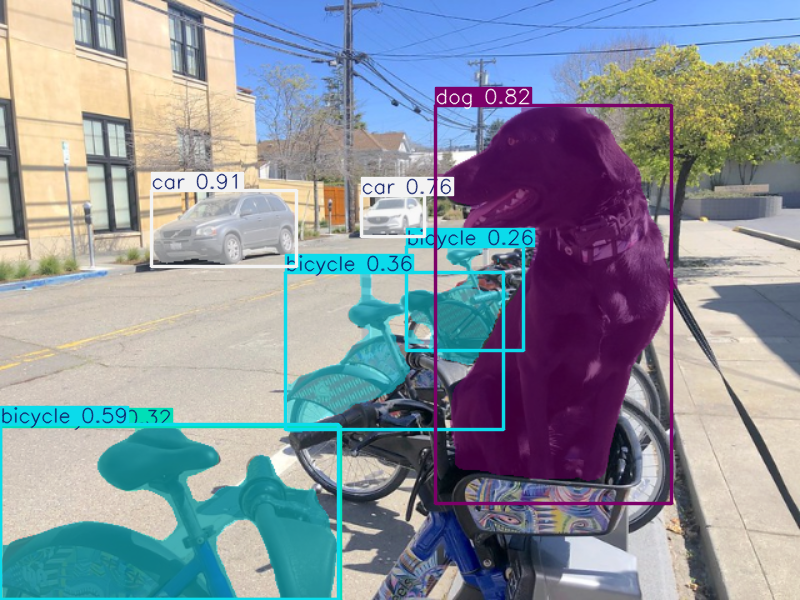

In [5]:
from PIL import Image
from ultralytics import YOLO

SEG_MODEL_NAME = model_name.value

seg_model = YOLO(f"{SEG_MODEL_NAME}.pt")
label_map = seg_model.model.names

res = seg_model(IMAGE_PATH)
Image.fromarray(res[0].plot()[:, :, ::-1])

### Convert model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Ultralytics provides API for convenient model exporting to different formats including OpenVINO IR. `model.export` is responsible for model conversion. We need to specify the format, and additionally, we can preserve dynamic shapes in the model.

In [6]:
# instance segmentation model
seg_model_path = Path(f"{SEG_MODEL_NAME}_openvino_model/{SEG_MODEL_NAME}.xml")
if not seg_model_path.exists():
    seg_model.export(format="openvino", dynamic=True, half=True)

Ultralytics 8.3.142 🚀 Python-3.10.12 torch-2.7.0+cpu CPU (Intel Core(TM) i9-10980XE 3.00GHz)

PyTorch: starting from 'yolo11n-seg.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 116, 8400), (1, 32, 160, 160)) (5.9 MB)

OpenVINO: starting export with openvino 2025.1.0-18503-6fec06580ab-releases/2025/1...
OpenVINO: export success ✅ 2.6s, saved as 'yolo11n-seg_openvino_model/' (6.0 MB)

Export complete (2.8s)
Results saved to /home/maleksandr/test_notebooks/yolo-device/openvino_notebooks/notebooks/yolov11-optimization
Predict:         yolo predict task=segment model=yolo11n-seg_openvino_model imgsz=640 half 
Validate:        yolo val task=segment model=yolo11n-seg_openvino_model imgsz=640 data=/ultralytics/ultralytics/cfg/datasets/coco.yaml half 
Visualize:       https://netron.app


### Verify model inference
[back to top ⬆️](#Table-of-contents:)

We can reuse the base model pipeline specifying Intel devices (intel:gpu, intel:npu, intel:cpu) when running inference with OpenVINO.

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO

In [7]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Test on single image
[back to top ⬆️](#Table-of-contents:)

In [8]:
seg_model = YOLO(seg_model_path.parent, task="segment")

Loading yolo11n-seg_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference...

image 1/1 /home/maleksandr/test_notebooks/yolo-device/openvino_notebooks/notebooks/yolov11-optimization/data/coco_bike.jpg: 480x640 3 bicycles, 2 cars, 1 motorcycle, 1 dog, 89.9ms
Speed: 3.9ms preprocess, 89.9ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)


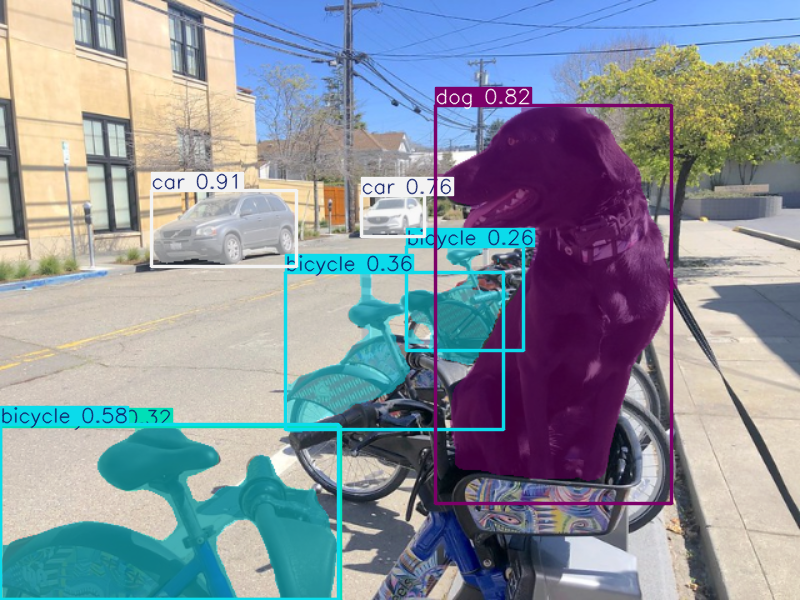

In [9]:
res = seg_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])

Great! The result is the same, as produced by original models.

## Optimize model using NNCF Post-training Quantization API
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides a suite of advanced algorithms for Neural Networks inference optimization in OpenVINO with minimal accuracy drop.
We will use 8-bit quantization in post-training mode (without the fine-tuning pipeline) to optimize YOLOv11.

The optimization process contains the following steps:

1. Create a Dataset for quantization.
2. Run `nncf.quantize` for getting an optimized model.
3. Serialize OpenVINO IR model, using the `openvino.save_model` function.

Please select below whether you would like to run quantization to improve model inference speed.

In [10]:
import ipywidgets as widgets

int8_model_seg_path = Path(f"{SEG_MODEL_NAME}_openvino_model_int8/{SEG_MODEL_NAME}.xml")
quantized_seg_model = None

to_quantize = widgets.Checkbox(
    value=True,
    description="Quantization",
    disabled=False,
)

to_quantize

Checkbox(value=True, description='Quantization')

Let's load `skip magic` extension to skip quantization if `to_quantize` is not selected

In [11]:
# Fetch skip_kernel_extension module
import requests


if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

Reuse validation dataloader in accuracy testing for quantization. 
For that, it should be wrapped into the `nncf.Dataset` object and define a transformation function for getting only input tensors.

In [12]:
%%skip not $to_quantize.value


import nncf

from zipfile import ZipFile

from ultralytics.data.utils import DATASETS_DIR
from ultralytics.utils import DEFAULT_CFG
from ultralytics.cfg import get_cfg
from ultralytics.data.converter import coco80_to_coco91_class
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import ops


if not int8_model_seg_path.exists():
    DATA_URL = "http://images.cocodataset.org/zips/val2017.zip"
    LABELS_URL = "https://github.com/ultralytics/yolov5/releases/download/v1.0/coco2017labels-segments.zip"
    CFG_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/v8.1.0/ultralytics/cfg/datasets/coco.yaml"

    OUT_DIR = DATASETS_DIR

    DATA_PATH = OUT_DIR / "val2017.zip"
    LABELS_PATH = OUT_DIR / "coco2017labels-segments.zip"
    CFG_PATH = OUT_DIR / "coco.yaml"

    if not (OUT_DIR / "coco/labels").exists():
        download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
        download_file(LABELS_URL, LABELS_PATH.name, LABELS_PATH.parent)
        download_file(CFG_URL, CFG_PATH.name, CFG_PATH.parent)
        with ZipFile(LABELS_PATH, "r") as zip_ref:
            zip_ref.extractall(OUT_DIR)
        with ZipFile(DATA_PATH, "r") as zip_ref:
            zip_ref.extractall(OUT_DIR / "coco/images")

    args = get_cfg(cfg=DEFAULT_CFG)
    args.data = str(CFG_PATH)
    seg_validator = seg_model.task_map[seg_model.task]["validator"](args=args)
    seg_validator.data = check_det_dataset(args.data)
    seg_validator.stride = 32
    seg_data_loader = seg_validator.get_dataloader(OUT_DIR / "coco/", 1)

    seg_validator.is_coco = True
    seg_validator.class_map = coco80_to_coco91_class()
    seg_validator.names = label_map
    seg_validator.metrics.names = seg_validator.names
    seg_validator.nc = 80
    seg_validator.nm = 32
    seg_validator.process = ops.process_mask
    seg_validator.plot_masks = []

    def transform_fn(data_item: dict):
        """
        Quantization transform function. Extracts and preprocess input data from dataloader item for quantization.
        Parameters:
           data_item: Dict with data item produced by DataLoader during iteration
        Returns:
            input_tensor: Input data for quantization
        """
        input_tensor = seg_validator.preprocess(data_item)["img"].numpy()
        return input_tensor

    quantization_dataset = nncf.Dataset(seg_data_loader, transform_fn)

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4722.9±1342.9 MB/s, size: 130.3 KB)


val: Scanning /home/maleksandr/test_notebooks/olmocr-check/openvino_notebooks/notebooks/yolov11-optimization/datasets/co


The `nncf.quantize` function provides an interface for model quantization. It requires an instance of the OpenVINO Model and quantization dataset. 
Optionally, some additional parameters for the configuration quantization process (number of samples for quantization, preset, ignored scope, etc.) can be provided. Ultralytics models contain non-ReLU activation functions, which require asymmetric quantization of activations. To achieve a better result, we will use a `mixed` quantization preset. It provides symmetric quantization of weights and asymmetric quantization of activations. For more accurate results, we should keep the operation in the postprocessing subgraph in floating point precision, using the `ignored_scope` parameter.

>**Note**: Model post-training quantization is time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [13]:
%%skip not $to_quantize.value

import shutil
import openvino as ov

core = ov.Core()
seg_ov_model = core.read_model(seg_model_path)


if not int8_model_seg_path.exists():
    ignored_scope = nncf.IgnoredScope(  # post-processing
        subgraphs=[
            nncf.Subgraph(inputs=[f"__module.model.{22 if 'v8' in SEG_MODEL_NAME else 23}/aten::cat/Concat",
                                  f"__module.model.{22 if 'v8' in SEG_MODEL_NAME else 23}/aten::cat/Concat_1",
                                  f"__module.model.{22 if 'v8' in SEG_MODEL_NAME else 23}/aten::cat/Concat_2",
                                 f"__module.model.{22 if 'v8' in SEG_MODEL_NAME else 23}/aten::cat/Concat_7"],
                          outputs=[f"__module.model.{22 if 'v8' in SEG_MODEL_NAME else 23}/aten::cat/Concat_8"])
        ]
    )

    # Segmentation model
    quantized_seg_model = nncf.quantize(
        seg_ov_model,
        quantization_dataset,
        preset=nncf.QuantizationPreset.MIXED,
        ignored_scope=ignored_scope
    )

    print(f"Quantized segmentation model will be saved to {int8_model_seg_path}")
    ov.save_model(quantized_seg_model, str(int8_model_seg_path))
    shutil.copy(seg_model_path.parent / "metadata.yaml", int8_model_seg_path.parent / "metadata.yaml")

/home/maleksandr/test_notebooks/yolo-device/openvino_notebooks/venv/lib/python3.10/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(


INFO:nncf:109 ignored nodes were found by subgraphs in the NNCFGraph
INFO:nncf:Not adding activation input quantizer for operation: 148 __module.model.23/aten::cat/Concat
INFO:nncf:Not adding activation input quantizer for operation: 158 __module.model.23/aten::view/Reshape_3
INFO:nncf:Not adding activation input quantizer for operation: 307 __module.model.23/aten::cat/Concat_1
INFO:nncf:Not adding activation input quantizer for operation: 318 __module.model.23/aten::view/Reshape_4
INFO:nncf:Not adding activation input quantizer for operation: 424 __module.model.23/aten::cat/Concat_2
INFO:nncf:Not adding activation input quantizer for operation: 428 __module.model.23/aten::view/Reshape_5
INFO:nncf:Not adding activation input quantizer for operation: 160 __module.model.23/aten::cat/Concat_7
INFO:nncf:Not adding activation input quantizer for operation: 171 __module.model.23/aten::cat/Concat_4
INFO:nncf:Not adding activation input quantizer for operation: 186 __module.model.23/prim::List

Output()

Output()

Quantized segmentation model will be saved to yolo11n-seg_openvino_model_int8/yolo11n-seg.xml


### Validate Quantized model inference
[back to top ⬆️](#Table-of-contents:)

`nncf.quantize` returns the OpenVINO Model class instance, which is suitable for loading on a device for making predictions. `INT8` model input data and output result formats have no difference from the floating point model representation. Therefore, we can reuse the same `detect` function defined above for getting the `INT8` model result on the image.

In [14]:
%%skip not $to_quantize.value

display(device)

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

Loading yolo11n-seg_openvino_model_int8 for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference...

image 1/1 /home/maleksandr/test_notebooks/yolo-device/openvino_notebooks/notebooks/yolov11-optimization/data/coco_bike.jpg: 480x640 2 bicycles, 2 cars, 1 motorcycle, 1 dog, 126.8ms
Speed: 4.2ms preprocess, 126.8ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)


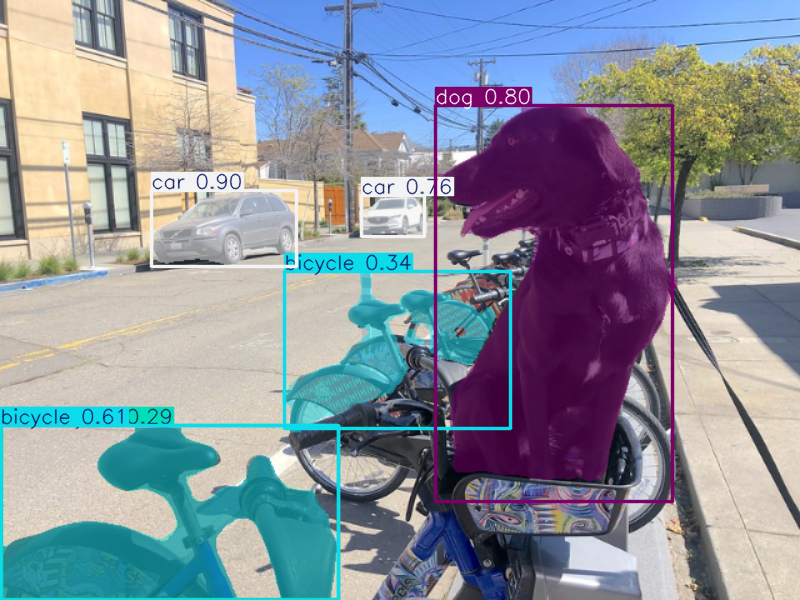

In [15]:
%%skip not $to_quantize.value

seg_model = YOLO(int8_model_seg_path.parent, task="segment")

device_name = device.value if device.value == "AUTO" else f"intel:{device.value.lower()}"
res = seg_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
display(Image.fromarray(res[0].plot()[:, :, ::-1]))

## Compare the Original and Quantized Models
[back to top ⬆️](#Table-of-contents:)


### Compare performance of the Original and Quantized Models
[back to top ⬆️](#Table-of-contents:)
Finally, use the OpenVINO [Benchmark Tool](https://docs.openvino.ai/2024/learn-openvino/openvino-samples/benchmark-tool.html) to measure the inference performance of the `FP32` and `INT8` models.

> **Note**: For more accurate performance, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications. Run `benchmark_app -m <model_path> -d CPU -shape "<input_shape>"` to benchmark async inference on CPU on specific input data shape for one minute. Change `CPU` to `GPU` to benchmark on GPU. Run `benchmark_app --help` to see an overview of all command-line options.

In [16]:
%%skip not $to_quantize.value

display(device)

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [17]:
if int8_model_seg_path.exists():
    !benchmark_app -m $seg_model_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2025.1.0-18503-6fec06580ab-releases/2025/1
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2025.1.0-18503-6fec06580ab-releases/2025/1
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 22.41 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [?,3,?,?]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_8) : f32 / [...] / [?,116,21..]
[ INFO ]     input.255 (node: __module.model.23.cv4.2.1.act/aten::silu_/Swish_46) : f3

In [18]:
if int8_model_seg_path.exists():
    !benchmark_app -m $int8_model_seg_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2025.1.0-18503-6fec06580ab-releases/2025/1
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2025.1.0-18503-6fec06580ab-releases/2025/1
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 29.72 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [?,3,?,?]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_8) : f32 / [...] / [?,116,21..]
[ INFO ]     input.255 (node: __module.model.23.cv4.2.1.act/aten::silu_/Swish_46) : f3

## Other ways to optimize model
[back to top ⬆️](#Table-of-contents:)

The performance could be also improved by another OpenVINO method such as async inference pipeline or preprocessing API.

Async Inference pipeline help to utilize the device more optimal. The key advantage of the Async API is that when a device is busy with inference, the application can perform other tasks in parallel (for example, populating inputs or scheduling other requests) rather than wait for the current inference to complete first. To understand how to perform async inference using openvino, refer to [Async API tutorial](../async-api/async-api.ipynb)

Preprocessing API enables making preprocessing a part of the model reducing application code and dependency on additional image processing libraries. 
The main advantage of Preprocessing API is that preprocessing steps will be integrated into the execution graph and will be performed on a selected device (CPU/GPU etc.) rather than always being executed on CPU as part of an application. This will also improve selected device utilization. For more information, refer to the overview of [Preprocessing API tutorial](../optimize-preprocessing/optimize-preprocessing.ipynb). To see, how it could be used with YOLOV8 object detection model, please, see [Convert and Optimize YOLOv8 real-time object detection with OpenVINO tutorial](./yolov8-object-detection.ipynb)

## Live demo
[back to top ⬆️](#Table-of-contents:)

The following code runs model inference on a video:

In [19]:
import collections
import time
import cv2
from IPython import display
import numpy as np


def run_instance_segmentation(
    source=0,
    flip=False,
    use_popup=False,
    skip_first_frames=0,
    model=seg_model,
    device=device.value,
    video_width: int = None,  # if not set the original size is used
):
    player = None

    try:
        # Create a video player to play with target fps.
        player = VideoPlayer(source=source, flip=flip, fps=30, skip_first_frames=skip_first_frames)
        # Start capturing.
        player.start()
        if use_popup:
            title = "Press ESC to Exit"
            cv2.namedWindow(winname=title, flags=cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()
        while True:
            # Grab the frame.
            frame = player.next()
            if frame is None:
                print("Source ended")
                break

            if video_width:
                # If the frame is larger than video_width, reduce size to improve the performance.
                # If more, increase size for better demo expirience.
                scale = video_width / max(frame.shape)
                frame = cv2.resize(
                    src=frame,
                    dsize=None,
                    fx=scale,
                    fy=scale,
                    interpolation=cv2.INTER_AREA,
                )

            # Get the results.
            input_image = np.array(frame)

            start_time = time.time()
            detections = seg_model(input_image, verbose=False, device=f"intel:{device.lower()}")
            stop_time = time.time()
            frame = detections[0].plot()

            processing_times.append(stop_time - start_time)
            # Use processing times from last 200 frames.
            if len(processing_times) > 200:
                processing_times.popleft()

            _, f_width = frame.shape[:2]
            # Mean processing time [ms].
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            cv2.putText(
                img=frame,
                text=f"Inference time: {processing_time:.1f}ms ({fps:.1f} FPS)",
                org=(20, 40),
                fontFace=cv2.FONT_HERSHEY_COMPLEX,
                fontScale=f_width / 1000,
                color=(0, 0, 255),
                thickness=1,
                lineType=cv2.LINE_AA,
            )
            # Use this workaround if there is flickering.
            if use_popup:
                cv2.imshow(winname=title, mat=frame)
                key = cv2.waitKey(1)
                # escape = 27
                if key == 27:
                    break
            else:
                # Encode numpy array to jpg.
                _, encoded_img = cv2.imencode(ext=".jpg", img=frame, params=[cv2.IMWRITE_JPEG_QUALITY, 100])
                # Create an IPython image.
                i = display.Image(data=encoded_img)
                # Display the image in this notebook.
                display.clear_output(wait=True)
                display.display(i)
    # ctrl-c
    except KeyboardInterrupt:
        print("Interrupted")
    # any different error
    except RuntimeError as e:
        print(e)
    finally:
        if player is not None:
            # Stop capturing.
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()

### Run Live Object Detection and Segmentation
[back to top ⬆️](#Table-of-contents:)

Use a webcam as the video input. By default, the primary webcam is set with `source=0`. If you have multiple webcams, each one will be assigned a consecutive number starting at 0. Set `flip=True` when using a front-facing camera. Some web browsers, especially Mozilla Firefox, may cause flickering. If you experience flickering, set `use_popup=True`.

>**NOTE**: To use this notebook with a webcam, you need to run the notebook on a computer with a webcam. If you run the notebook on a remote server (for example, in Binder or Google Colab service), the webcam will not work. By default, the lower cell will run model inference on a video file. If you want to try live inference on your webcam set `WEBCAM_INFERENCE = True`

In [20]:
WEBCAM_INFERENCE = False

if WEBCAM_INFERENCE:
    VIDEO_SOURCE = 0  # Webcam
else:
    VIDEO_SOURCE = Path("people.mp4")
    if not VIDEO_SOURCE.exists():
        download_file(
            "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/people.mp4",
            "people.mp4",
        )

In [21]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

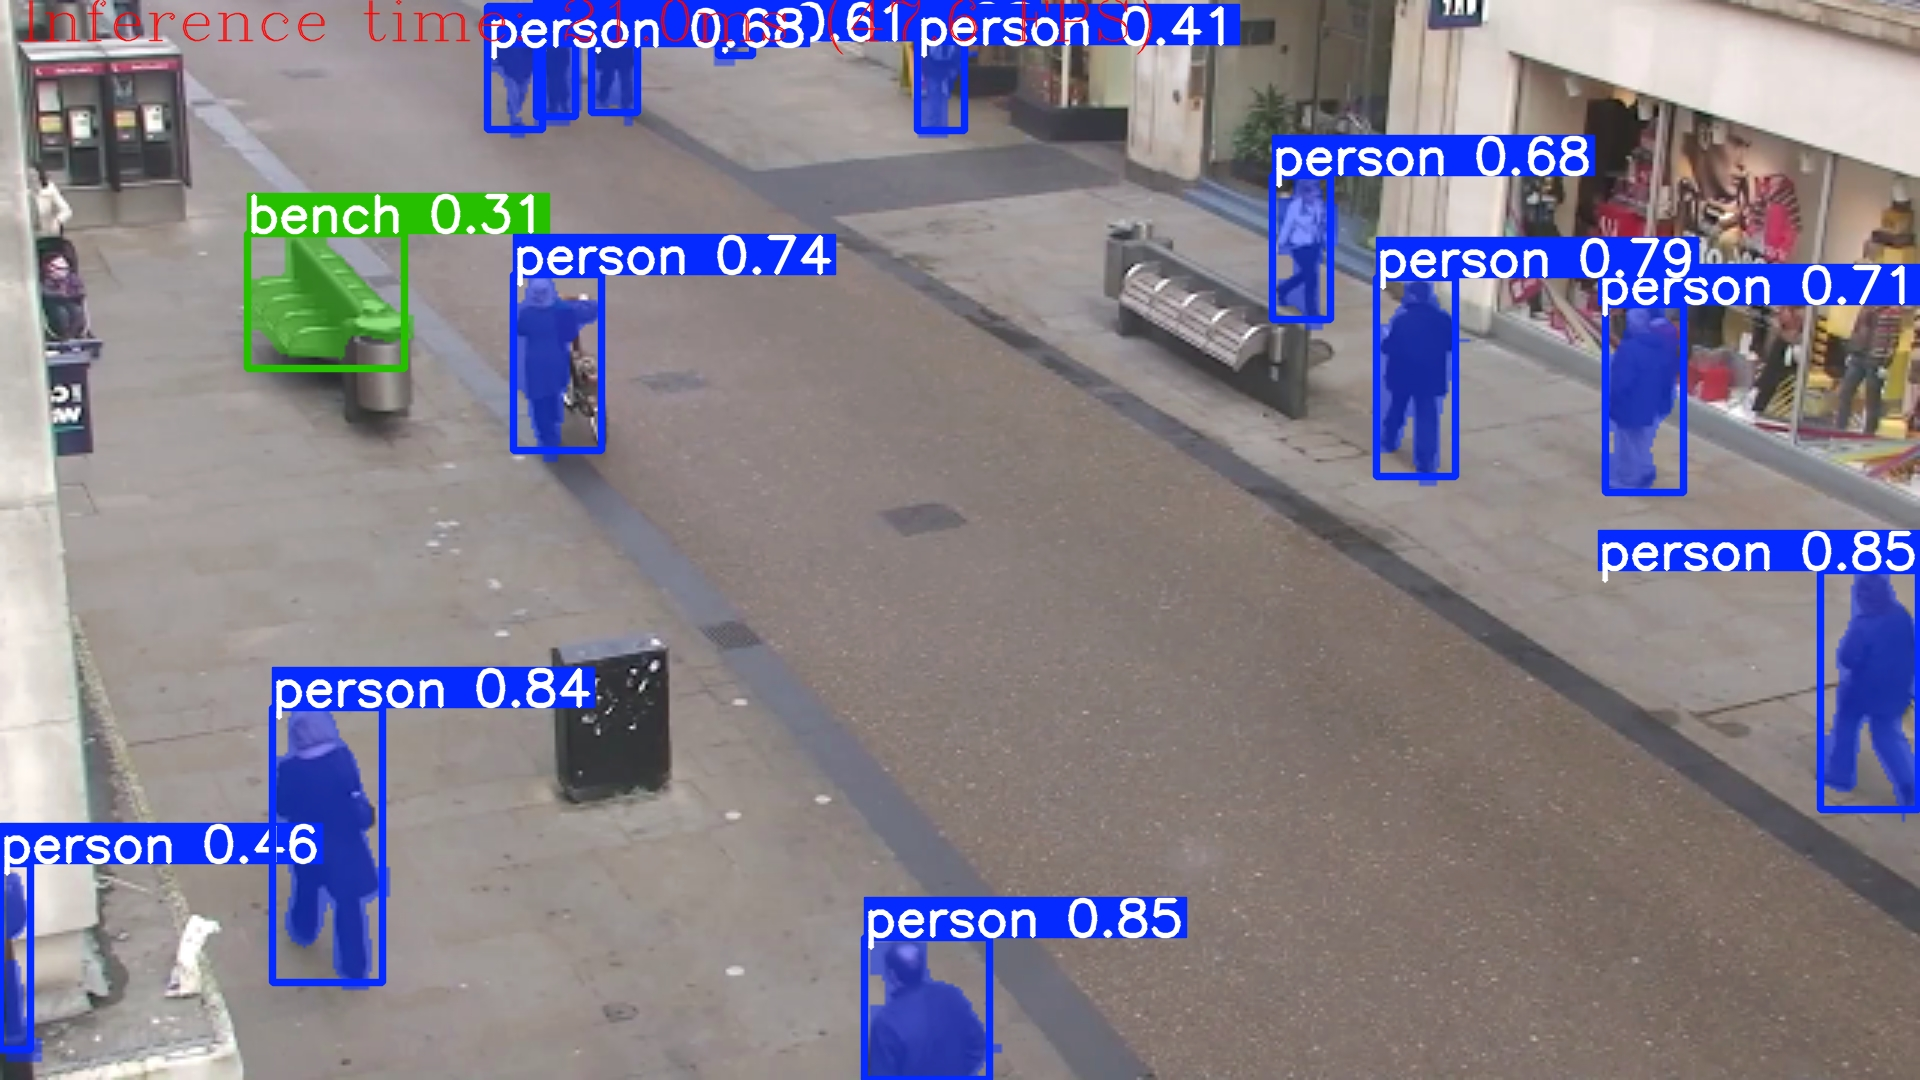

Source ended


In [22]:
run_instance_segmentation(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=False,
    model=seg_model,
    device=device.value,
    # video_width=1280,
)